# Replica of the scITD Analysis

The goal of this ntoebook is to replicate, on the breast-cancer data which is provided, the analysis which scITD conducts in order to gain insight on how tensor decompositions can be used to meaningfully analyse cell-cycle data.

## 0. Imports:

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import tensorly as tl
from tensorly import tenalg

---

## 1. Data import:

In [31]:
from pathlib import Path

data_dir = Path("../data/breast_cancer_zikry_wayne")
h5ad_files = sorted(data_dir.glob("*.h5ad"))
if not h5ad_files:
    raise FileNotFoundError(f"No .h5ad files found in {data_dir}")

adatas = [sc.read_h5ad(str(p)) for p in h5ad_files]

adata = sc.concat(
    adatas,
    join="outer",
    label="source_file",
    keys=[p.stem for p in h5ad_files],
    index_unique="-",
)

adata.obs["source_file"] = adata.obs["source_file"].str.removesuffix("_merged").values

We subset to the intersection of the proteins selected in $\texttt{Selected features.ipynb}$:

In [32]:
features_44PE = [
    'nuclear_mean_pH2AX','nuclear_mean_53BP1', 'nuclear_mean_ECad', 
    'nuclear_mean_HER2', 'nuclear_mean_cycD1', 'nuclear_mean_CDK4',
    'nuclear_mean_cycE1', 'nuclear_mean_HES1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 
    'DNA_int', 'nuclear_mean_CycB1'
]

features_134 = [
    'nuclear_mean_CDK4', 'nuclear_mean_cycE1', 'nuclear_mean_pH2AX', 
    'nuclear_mean_53BP1','nuclear_mean_p16', 'nuclear_mean_pRB',
    'nuclear_mean_PH3','nuclear_mean_cycA2','nuclear_mean_Plk1',
    'DNA_int'
]

features_231 = [
    'nuclear_mean_cycD1', 'nuclear_mean_CDK4', 'nuclear_mean_pH2AX', 
    'nuclear_mean_ERa', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
    'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
]

features_453 = [
    'nuclear_mean_pH2AX', 'nuclear_mean_pAKT', 'nuclear_mean_CDK4',
    'nuclear_mean_RB', 'nuclear_mean_CDK2', 'nuclear_mean_CycB1',
    'nuclear_mean_cycD1', 'nuclear_mean_cycE1', 'nuclear_mean_CDC25c', 
    'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
    'nuclear_mean_Plk1', 'DNA_int'
]

features_BCK4 = [
    'nuclear_mean_HES1', 'nuclear_mean_pH2AX', 'nuclear_mean_bCat',
    'nuclear_mean_ERa', 'nuclear_mean_DAPI', 'nuclear_mean_CDK4',
    'nuclear_mean_pRB', 'nuclear_mean_PH3', 'nuclear_mean_cycA2',
    'nuclear_mean_Plk1', 'DNA_int'
]

features_MCF7 = [
    'nuclear_mean_HER2', 'nuclear_mean_cycE1', 'cyto_mean_CDC25c',
    'cyto_mean_PR', 'cyto_mean_p21', 'nuclear_mean_CDC25c',
    'nuclear_mean_cycA1', 'nuclear_mean_pRB', 'nuclear_mean_PH3',
    'nuclear_mean_cycA2', 'nuclear_mean_Plk1', 'DNA_int'
]

features_T47D = [
    'nuclear_mean_HES1', 'nuclear_mean_p53', 'nuclear_mean_pH2AX', 
    'nuclear_mean_CDC25c', 'nuclear_mean_CycB1', 'nuclear_mean_p16',
    'nuclear_mean_CDK2', 'nuclear_mean_cycE1', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
    'DNA_int'
]

features_MCF10A = [
    'nuclear_mean_ERa', 'nuclear_mean_pRB', 'pRB/RB', 
    'nuclear_mean_HES1', 'nuclear_mean_Ki67', 'nuclear_mean_cycB2',
    'nuclear_mean_cycD1', 'nuclear_mean_RB', 'nuclear_mean_pRB',
    'nuclear_mean_PH3', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
    'DNA_int'
]


In [33]:
selected_features = list(
    set(features_44PE) 
    & set(features_134)
    & set(features_231)
    & set(features_453)
    & set(features_BCK4)
    & set(features_MCF7)
    & set(features_T47D)
    & set(features_MCF10A)
)

adata = adata[:, selected_features]

Understanding our data:

In [34]:
print(f'n_obs x n_vars: {adata.shape}')

n_obs x n_vars: (2121333, 5)


In [35]:
print(f'cell barcodes (row index): {adata.obs_names}\n')
print(f'gene/feature names (column index): {adata.var_names}\n')

cell barcodes (row index): Index(['0-134_merged', '1-134_merged', '2-134_merged', '3-134_merged',
       '4-134_merged', '5-134_merged', '6-134_merged', '7-134_merged',
       '8-134_merged', '9-134_merged',
       ...
       '144088-T47D_merged', '144089-T47D_merged', '144090-T47D_merged',
       '144091-T47D_merged', '144092-T47D_merged', '144093-T47D_merged',
       '144094-T47D_merged', '144095-T47D_merged', '144096-T47D_merged',
       '144097-T47D_merged'],
      dtype='object', length=2121333)

gene/feature names (column index): Index(['nuclear_mean_pRB', 'nuclear_mean_cycA2', 'nuclear_mean_Plk1',
       'DNA_int', 'nuclear_mean_PH3'],
      dtype='object')



In [36]:
adata.obs

,core,binucleated,CellID,GMM_phase_labels,DNA_int_obs,nuclear_mean_cycA2_obs,Endocycle,drug_name,source_file
0-134_merged,1.0,0,0,G1,2.852778,174.067138,Diploid,Control,134
1-134_merged,1.0,0,1,G2,4.277782,7286.788861,Diploid,Control,134
2-134_merged,1.0,0,2,M,3.825389,4637.076161,Diploid,Control,134
3-134_merged,1.0,0,3,G1,2.058231,91.620798,Diploid,Control,134
4-134_merged,1.0,0,4,S,2.739487,2175.699147,Diploid,Control,134
...,...,...,...,...,...,...,...,...,...
144093-T47D_merged,8.0,0,144093,G1,2.205912,240.395580,Diploid,Dinaciclib,T47D
144094-T47D_merged,8.0,0,144094,G1,2.033355,193.921158,Diploid,Dinaciclib,T47D
144095-T47D_merged,8.0,0,144095,G0,2.081168,531.183796,Diploid,Dinaciclib,T47D
144096-T47D_merged,8.0,0,144096,G0,1.971715,174.206118,Diploid,Dinaciclib,T47D


In [37]:
total = adata.obs['drug_name'].value_counts().sum()
adata.obs['drug_name'].value_counts() / total

drug_name
RO-3306         0.301241
Palbociclib     0.140028
Control         0.125868
CVT-313         0.121824
Dinaciclib      0.106363
Talazoparib     0.077380
PF-3600         0.064703
Samuraciclib    0.062594
Name: count, dtype: float64

In [38]:
pd.DataFrame(adata.X, columns=adata.var_names, index=adata.obs_names)

,nuclear_mean_pRB,nuclear_mean_cycA2,nuclear_mean_Plk1,DNA_int,nuclear_mean_PH3
0-134_merged,2598.838634,174.067138,183.088339,2.852778,772.422850
1-134_merged,3093.479634,7286.788861,498.014963,4.277782,1836.716542
2-134_merged,3020.639756,4637.076161,311.682407,3.825389,11301.259711
3-134_merged,2442.421218,91.620798,187.529412,2.058231,619.453782
4-134_merged,3132.432400,2175.699147,226.690621,2.739487,1055.071864
...,...,...,...,...,...
144093-T47D_merged,1109.131492,240.395580,182.297238,2.205912,589.051934
144094-T47D_merged,578.515968,193.921158,507.659681,2.033355,1085.689621
144095-T47D_merged,384.794449,531.183796,223.363091,2.081168,385.189047
144096-T47D_merged,173.493176,174.206118,161.687529,1.971715,359.054118


In [39]:
condition_G0_M = (~adata.obs['GMM_phase_labels'].isin(['G0', 'M']))
adata_sans_G0_M = adata[condition_G0_M]

Calculating PHATE...
  Running PHATE on 10000 observations and 5 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.06 seconds.
    Calculating affinities...
    Calculated affinities in 0.11 seconds.
  Calculated graph and diffusion operator in 0.17 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.20 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.32 seconds.
  Calculated landmark operator in 1.52 seconds.
  Calculating optimal t...
    Automatically selected t = 23
  Calculated optimal t in 1.05 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.31 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -2.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 1.15 seconds.
Calculated PHATE in 4.43 seconds.


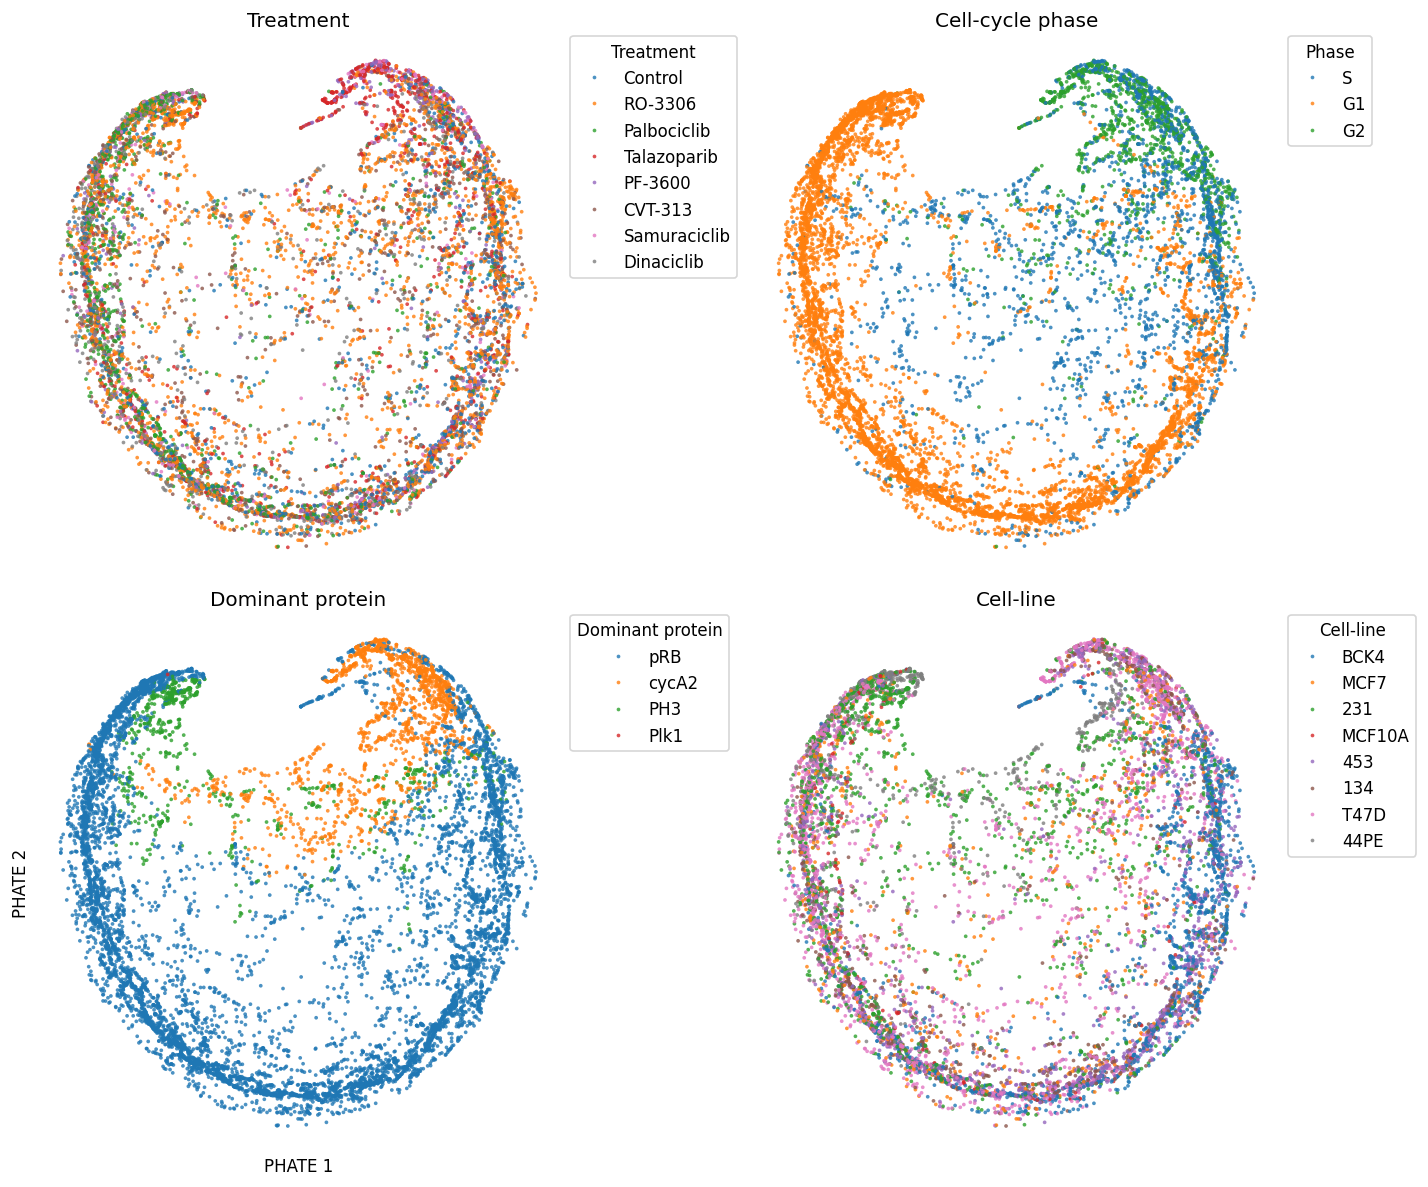

In [71]:
import phate

dot_size = 5

# PHATE on sampled data
adata_sub = sc.pp.subsample(adata_sans_G0_M, n_obs=min(10000, adata_sans_G0_M.n_obs), copy=True, random_state=0)
phate_op = phate.PHATE()
data_phate = phate_op.fit_transform(adata_sub.X)
dominant_protein = adata_sub[:, selected_features].to_df().idxmax(axis=1)
cell_line = adata_sub.obs["source_file"].astype(str).values

phate = pd.DataFrame(
    data_phate, 
    columns=["PHATE 1", "PHATE 2"],
    index=adata_sub.obs_names,
)

phate["treatment"] = adata_sub.obs["drug_name"].astype(str).values
phate["phase"] = adata_sub.obs["GMM_phase_labels"].astype(str).values
phate["protein"] = np.asarray(adata_sub[:, "DNA_int"].X).ravel()
phate["dominant_protein"] = dominant_protein.str.removeprefix("nuclear_mean_").values
phate["cell_line"] = cell_line


# Set up visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
sns.despine(top=True, right=True, left=True, bottom=True)


# Treatment
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="treatment",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Treatment")
axes[0].legend(title="Treatment", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Cell-cycle phase
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="phase",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[1]
)
axes[1].set_title("Cell-cycle phase")
axes[1].legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


# Dominant protein per sample
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="dominant_protein",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[2]
)
axes[2].set_title("Dominant protein")
axes[2].legend(
    title="Dominant protein", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Cell-line
sns.scatterplot(
    data=phate, x="PHATE 1", y="PHATE 2", hue="cell_line",
    s=dot_size, linewidth=0, alpha=0.8, ax=axes[3]
)
axes[3].set_title("Cell-line")
axes[3].legend(
    title="Cell-line", bbox_to_anchor=(1.02, 1),
    loc="upper left", borderaxespad=0
)


# Final touches
for ax in axes:
    if ax == axes[2]: 
        ax.set_xlabel("PHATE 1")
        ax.set_ylabel("PHATE 2")
    else: 
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

---

## 2. Data analysis:

We model our tensor via: $\textit{treatment} \times \textit{cell-cycle phase} \times \textit{protein} \times \textit{cell-line}$. Let $t \in \mathbb{N}$ be the number of treatments, in our case $t = 8$, let $c \in \mathbb{N}$ the number of cell-cycle phases, here $c = 5$, let $p \in \mathbb{N}$ be the number of proteins analyzed, here $p = 13$, and let $l \in \mathbb{N}$ be the number of cell-lines analyzed, here $l = 8$. After performing a Tucker decomposition on said tensor, we may obtain: 

$$
\begin{split}
X & \approx \mathcal{G} \times_1 T \times_2 C \times_3 P \times_4 L \\
        & = (\mathcal{G} \times_2 C \times_3 P \times_4 L) \times_1 T \\
        & = \mathcal{F} \times_1 T 
\end{split}
$$

where $T \in \mathbb{R}^{t_F \times t}$ are the treatment loadings, $C \in \mathbb{R}^{c_F \times c}$ are the cell-cycle-phase loadings, $P \in \mathbb{R}^{p_F \times p}$ are the protein loadings, $L \in \mathbb{R}^{l_F \times l}$ are the cell-line loadings, and $\mathcal{F} \in \mathbb{R}^{t_F \times c \times p \times l}$ is a tensor encoding the effect of the treatment-factors on the cell-cycle across proteins and cell-lines. (Note that $t_F$, $c_F$, $p_F$, and $l_F$ denote the treatment-facotrs, cell-cycle-phase-factors, protein-factors, and cell-line-factors respectively.)

### 2.1 Pseudobulking:

Similar to Mitchel et al. (2025), we perform pseudobulking, averaging proteins within each $\texttt{(treatment, cell-cycle-phase, cell-line)}$ and obtaining our tensor by stacking across proteins and cell-lines.

In [52]:
def pseudobulk(adata):
    # Convert AnnData to DataFrame 
    adata_df = adata.to_df()
    
    # Group by drug_name and GMM_phase_labels, then get mean of each group
    pseudobulk_df = adata_df.groupby([adata.obs["drug_name"], adata.obs["GMM_phase_labels"], adata.obs["source_file"]], observed=True).mean()
    
    # z-scale across each protein 
    pseudobulk_df_scales = (pseudobulk_df - pseudobulk_df.mean()) / pseudobulk_df.std()
    
    # Reshape to (n_drugs, n_phases, n_features, n_cell_lines)
    return_tensor = pseudobulk_df_scales.values.reshape(len(adata.obs["drug_name"].cat.categories), len(adata.obs["GMM_phase_labels"].cat.categories), -1, len(np.unique(adata.obs["source_file"])))
    return return_tensor

In [54]:
pseudobulk_tensor = pseudobulk(adata_sans_G0_M)
print(f'Pseudobulk tensor shape: {pseudobulk_tensor.shape}')

print("Example pseudobulk values for the first protein (HES1), in fist cell-line:")
pd.DataFrame(pseudobulk_tensor[:, :, 0, 0], index=adata_sans_G0_M.obs["drug_name"].cat.categories, columns=adata_sans_G0_M.obs["GMM_phase_labels"].cat.categories)

Pseudobulk tensor shape: (8, 3, 5, 8)
Example pseudobulk values for the first protein (HES1), in fist cell-line:


,G1,G2,S
CVT-313,-0.497666,0.192799,0.023930
Control,-0.343512,0.501184,0.210591
Dinaciclib,-0.770969,-0.125365,-0.338207
PF-3600,0.061191,0.892665,0.626086
Palbociclib,-0.284519,0.178467,0.048953
RO-3306,-0.441884,0.561106,0.335578
Samuraciclib,-0.401795,0.639851,0.265760
Talazoparib,-0.483897,0.723255,0.299281


In [66]:
drugs = list(adata_sans_G0_M.obs["drug_name"].cat.categories)
phases = list(adata_sans_G0_M.obs["GMM_phase_labels"].cat.categories)
proteins = [f.replace("nuclear_mean_", "") for f in selected_features]
cell_lines = list(np.unique(adata_sans_G0_M.obs["source_file"]))

### 2.2 Perform tensor decomposition:

In [67]:
def HOSVD(tensor, truncation_rank=None):
    dims = tensor.shape
    
    if truncation_rank is None:
        truncation_rank = dims
    
    factors = []
    for i, _ in enumerate(dims): 
        matrix = tl.unfold(tensor, mode=i)
        
        rank = np.linalg.matrix_rank(matrix)
        factor = np.linalg.svd(matrix, full_matrices=False)[0][:, :rank]
        
        factors.append(factor[:, :truncation_rank[i]])
    
    factors_transposed = [f.T for f in factors]
    
    core = tenalg.multi_mode_dot(tensor, factors_transposed)
        
    return core, factors

In [68]:
core, factors = HOSVD(pseudobulk_tensor)

### 2.2 Tensor visualization:

In [78]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "image.cmap": "RdBu_r",
})

**1) Factor matrices $U_0$, $U_1$, $U_2$, $U_3$:**

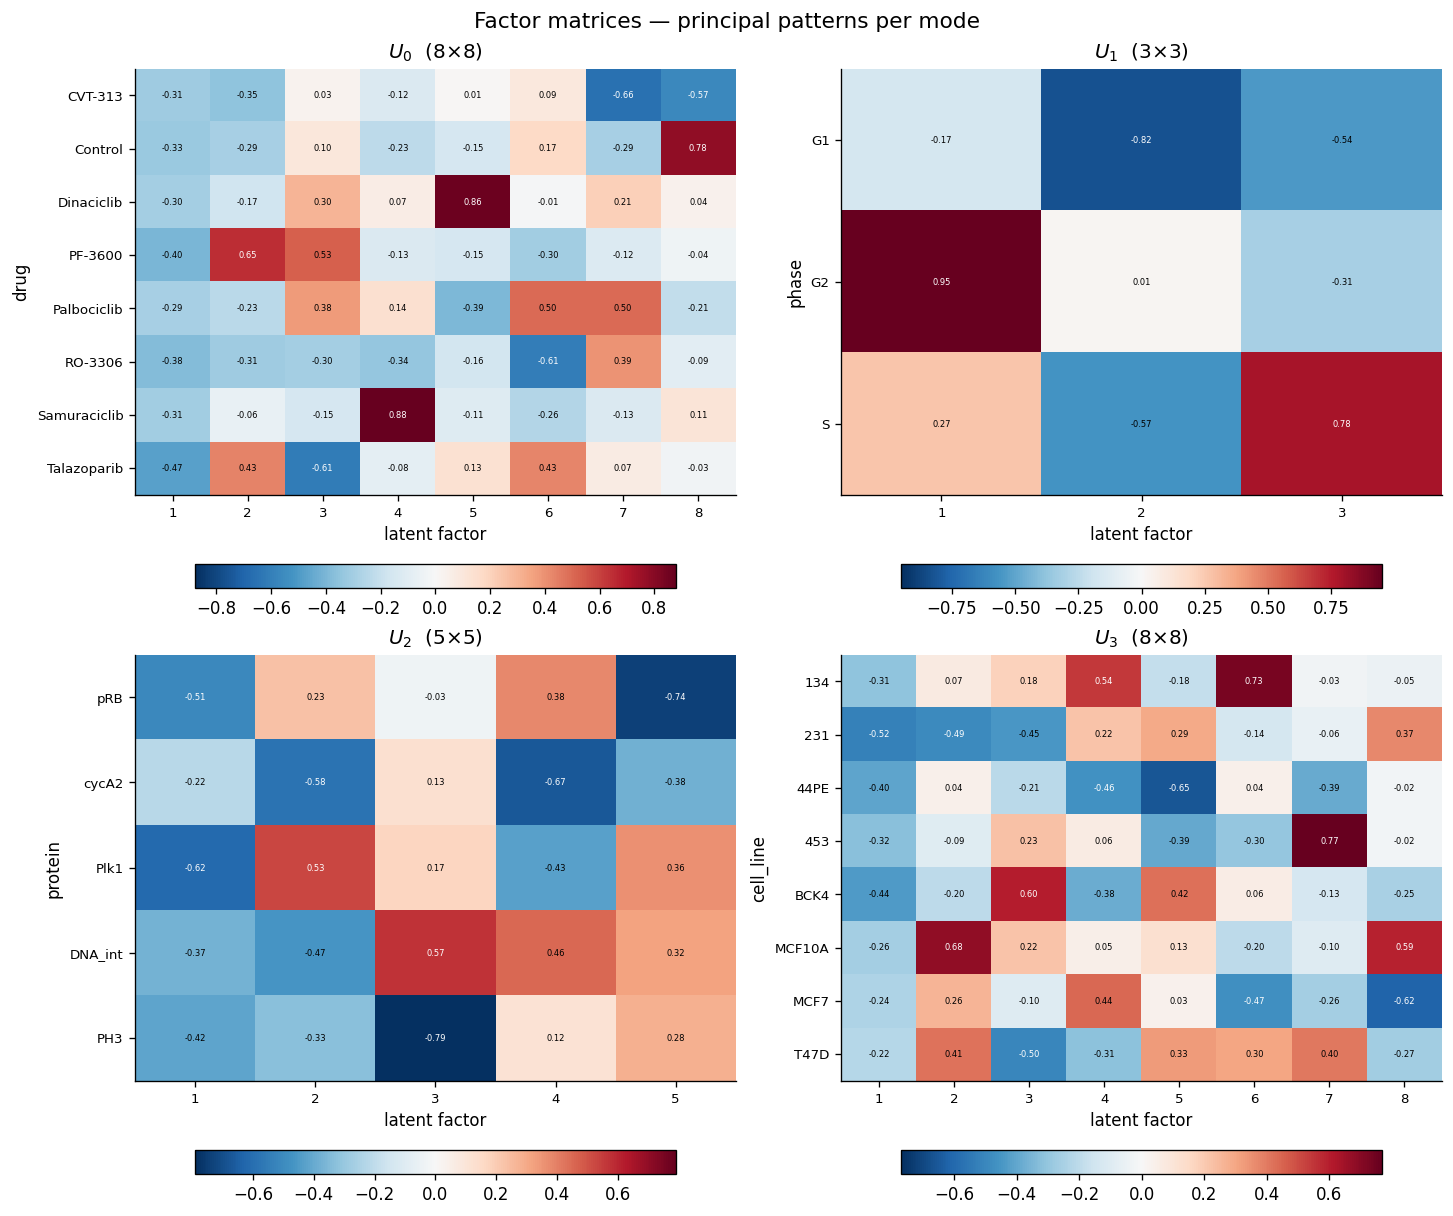

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True, squeeze=False)
axes = axes.flatten()

panels = [
    (factors[0], "U_0", "drug", drugs),
    (factors[1], "U_1", "phase", phases),
    (factors[2], "U_2", "protein", proteins),
    (factors[3], "U_3", "cell_line", cell_lines)
]

for ax, (U, name, rowname, rowlabs) in zip(axes, panels):
    vmax = np.abs(U).max() or 1.0
    
    im = ax.imshow(U, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    
    ax.set_title(rf"${name}$  ({U.shape[0]}$\times${U.shape[1]})", fontsize=12)
    ax.set_xticks(np.arange(U.shape[1])); ax.set_xticklabels(np.arange(1, U.shape[1] + 1), fontsize=8)
    ax.set_xlabel("latent factor", fontsize=10)
    ax.set_yticks(np.arange(U.shape[0])); ax.set_yticklabels(rowlabs, fontsize=8)
    ax.set_ylabel(rowname, fontsize=10)
    
    if U.size <= 100:  # annotate small matrices
        for i in range(U.shape[0]):
            for j in range(U.shape[1]):
                ax.text(
                    j, i, f"{U[i, j]:.2f}", ha="center", va="center", fontsize=5,
                    color="white" if abs(U[i, j]) > 0.6 * vmax else "black"
                )
                
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, pad=0.04)

fig.suptitle("Factor matrices — principal patterns per mode", fontsize=13)
plt.show()

---